<a href="https://colab.research.google.com/github/carlos-000-carlos/Challenge_2-TelecomX_BR-Cabral/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extração

In [54]:
# importando as bibliotecas necessárias para extração e normalização dos dados
import pandas as pd
import requests
import json

In [55]:
# Carregamento e extração dos dados, já aplicando a normalização para visualização do Dataframe
dados = requests.get('https://raw.githubusercontent.com/carlos-000-carlos/Challenge_2-TelecomX_BR-Cabral/refs/heads/main/TelecomX_Data.json')
resultado  = json.loads(dados.text)
dados_normalizados_api = pd.json_normalize(resultado, sep = '_')
dados_normalizados_api = pd.DataFrame(dados_normalizados_api)
dados_normalizados_api.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



🔍 **Análise da Estrutura dos Dados**
Os dados são organizados em um formato hierárquico (dicionário dentro de dicionário), contendo as seguintes informações:

1. **Identificação do Cliente**  
   - `'customerID'`: Identificador único do cliente.  
   - `'Churn'`: Indica se o cliente cancelou o serviço (`Yes` ou `No`).  

2. **Informações do Cliente** (`'customer'`)  
   - `'gender'`: Gênero do cliente (`Male` ou `Female`).  
   - `'SeniorCitizen'`: Indica se o cliente é idoso (0 = Não, 1 = Sim).  
   - `'Partner'`: Se o cliente tem um parceiro(a).  
   - `'Dependents'`: Se o cliente tem dependentes.  
   - `'tenure'`: Tempo de permanência como cliente (em meses).  

3. **Serviços de Telefonia** (`'phone'`)  
   - `'PhoneService'`: Indica se o cliente possui serviço de telefone (`Yes` ou `No`).  
   - `'MultipleLines'`: Se possui múltiplas linhas telefônicas.  

4. **Serviços de Internet** (`'internet'`)  
   - Tipo de serviço de internet contratado (`DSL`, `Fiber optic`, `No`).  
   - Serviços adicionais (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).  

5. **Informações da Conta** (`'account'`)  
   - `'Contract'`: Tipo de contrato (`Month-to-month`, `One year`, `Two year`).  
   - `'PaperlessBilling'`: Se o cliente recebe faturas eletrônicas.  
   - `'PaymentMethod'`: Método de pagamento (`Bank transfer`, `Credit card`, `Electronic check`, `Mailed check`).  
   - `'Charges'`:  
     - `'Monthly'`: Valor mensal cobrado.  
     - `'Total'`: Valor total pago pelo cliente.  



#🔧 Transformação

##Conhecendo o Dataset

In [56]:
dados_normalizados_api

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [57]:
# Explorando as colunas do dataset e verificando seus tipos de dados
dados_normalizados_api.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

## Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa
* `gender`: gênero (masculino e feminino)
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico
* `MultipleLines`: assisnatura de mais de uma linha de telefone
* `InternetService`: assinatura de um provedor internet
* `OnlineSecurity`: assinatura adicional de segurança online
* `OnlineBackup`: assinatura adicional de backup online
* `DeviceProtection`: assinatura adicional de proteção no dispositivo
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo
* `StreamingMovies`: assinatura de streaming de filmes
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

**Verificações iniciais a serem feitas no DataFrame**

**Passo 1:** Verificação dos valores únicos de cada coluna

In [58]:
# Criamos uma lista com os nomes das colunas do Dataframe
colunas = list(dados_normalizados_api.columns)
colunas

['customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges_Monthly',
 'account_Charges_Total']

In [59]:
# Aplicando o método "unique" a várias colunas de uma só vez
valores_unicos = dados_normalizados_api[colunas].apply(pd.Series.unique)
print(valores_unicos)

customerID                   [0002-ORFBO, 0003-MKNFE, 0004-TLHLJ, 0011-IGKF...
Churn                                                              [No, Yes, ]
customer_gender                                                 [Female, Male]
customer_SeniorCitizen                                                  [0, 1]
customer_Partner                                                     [Yes, No]
customer_Dependents                                                  [Yes, No]
customer_tenure              [9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...
phone_PhoneService                                                   [Yes, No]
phone_MultipleLines                                [No, Yes, No phone service]
internet_InternetService                                [DSL, Fiber optic, No]
internet_OnlineSecurity                         [No, Yes, No internet service]
internet_OnlineBackup                           [Yes, No, No internet service]
internet_DeviceProtection                       [No,

**Passo 2:** Verificação dos valores duplicados de cada coluna

In [60]:
# Aplicando o método "duplicated" a várias colunas de uma só vez
print('Número de valores duplicados: ', dados_normalizados_api.duplicated().sum())

Número de valores duplicados:  0


**Passo 3:** Verificação dos valores nulos de cada coluna

In [61]:
# Aplicando o método "isnull" a várias colunas de uma só vez
print('Número de valores nulos: ', dados_normalizados_api.isnull().sum())

Número de valores nulos:  customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges_Monthly      0
account_Charges_Total        0
dtype: int64


**Passo 4:** Verificação dos valores vazios ou em branco de cada coluna

In [62]:
# Aplicando o método "strip" a várias colunas de uma só vez
dados_normalizados_api.apply(lambda x: x.astype(str).str.strip().eq('').sum())

,0
customerID,0
Churn,224
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


**Tranformação 1:** convertendo os valores da coluna "account_Charges_Total" para o tipo "float64"

In [63]:
# Aplicando o método "to_numeric" para transformar em float
dados_normalizados_api['account_Charges_Total'] = pd.to_numeric(dados_normalizados_api['account_Charges_Total'], errors = 'coerce')
dados_normalizados_api.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

**Transformação 2:** excluindo linhas vazias da coluna "Churn"

In [64]:
# Aplicando o método "strip" a várias colunas de uma só vez
dados_normalizados_api.apply(lambda x: x.astype(str).str.strip().eq('').sum())

,0
customerID,0
Churn,224
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [65]:
# Eliminando linhas da coluna "Churn" que possuíam dados vazios
dados_normalizados_api = dados_normalizados_api[dados_normalizados_api['Churn'].str.strip() != '']
print('Número de linhas após eliminação das linhas que continham dados vazios na coluna "Churn": ', len(dados_normalizados_api))

Número de linhas após eliminação das linhas que continham dados vazios na coluna "Churn":  7043


In [66]:
# verificando valores vazios novamente
dados_normalizados_api.apply(lambda x: x.astype(str).str.strip().eq('').sum())

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


**Transformação 3:** Eliminando valorfes nulos na coluna "account_Charges_Total"

In [67]:
# Verficando os valores nulos através do método "isnull"
print('Quantidade de números nulos\n\n', dados_normalizados_api.isnull().sum())

Quantidade de números nulos

 customerID                    0
Churn                         0
customer_gender               0
customer_SeniorCitizen        0
customer_Partner              0
customer_Dependents           0
customer_tenure               0
phone_PhoneService            0
phone_MultipleLines           0
internet_InternetService      0
internet_OnlineSecurity       0
internet_OnlineBackup         0
internet_DeviceProtection     0
internet_TechSupport          0
internet_StreamingTV          0
internet_StreamingMovies      0
account_Contract              0
account_PaperlessBilling      0
account_PaymentMethod         0
account_Charges_Monthly       0
account_Charges_Total        11
dtype: int64


In [68]:
# Removendo linhas com qualquer valor nulo
dados_normalizados_api = dados_normalizados_api.dropna()

In [69]:
# Verficando os valores nulos através do método "isnull"
print('Quantidade de números nulos\n\n', dados_normalizados_api.isnull().sum())

Quantidade de números nulos

 customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges_Monthly      0
account_Charges_Total        0
dtype: int64


**Transformação 4:** Criação da coluna "contas_diarias" (Opcional)

In [70]:
dados_normalizados_api

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [71]:
# Criando a coluna "contas_diarias"
dados_normalizados_api['contas_diarias'] = dados_normalizados_api['account_Charges_Monthly'] / 30

In [72]:
dados_normalizados_api

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


**Transformação 5:** padronizando o noe das colunas para melhor entendimento e traduzindo para português (Opcional)

In [73]:
# lista das colunas
colunas

['customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges_Monthly',
 'account_Charges_Total']

In [74]:
# novos nomes para as colunas
colunas_padronizadas = ['id',
                        'Churn',
                        'genero',
                        'tem_mais_de_60',
                        'tem_parceiro',
                        'tem_dependentes',
                        'tempo_de_contrato',
                        'servico_de_telefone',
                        'tem_multiplas_linhas',
                        'tipo_de_internet',
                        'tem_seguranca_online',
                        'tem_backup_online',
                        'tem_protecao_dispositivo',
                        'tem_suporte_tecnico',
                        'tem_streaming_tv',
                        'tem_streaming_filmes',
                        'tipo_de_contrato',
                        'tem_fatura_digital',
                        'metodo_de_pagamento',
                        'valor_mensal',
                        'valor_total_cobrado']

In [75]:
# loop para mudar os nomes das colunas uma a uma
for antigo, novo in zip(colunas, colunas_padronizadas):
  dados_normalizados_api.rename(columns = {antigo : novo}, inplace = True)

In [76]:
pd.set_option('display.max_columns', None)

In [77]:
dados_normalizados_api

,id,Churn,genero,tem_mais_de_60,tem_parceiro,tem_dependentes,tempo_de_contrato,servico_de_telefone,tem_multiplas_linhas,tipo_de_internet,tem_seguranca_online,tem_backup_online,tem_protecao_dispositivo,tem_suporte_tecnico,tem_streaming_tv,tem_streaming_filmes,tipo_de_contrato,tem_fatura_digital,metodo_de_pagamento,valor_mensal,valor_total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


**Transformação 6:** padronizando os dados das colunas para melhor entendimento e traduzindo para português (Opcional)

In [78]:
# Criamos uma lista com os nomes das colunas do Dataframe
colunas_traduzidas = dados_normalizados_api.columns
colunas_traduzidas

Index(['id', 'Churn', 'genero', 'tem_mais_de_60', 'tem_parceiro',
       'tem_dependentes', 'tempo_de_contrato', 'servico_de_telefone',
       'tem_multiplas_linhas', 'tipo_de_internet', 'tem_seguranca_online',
       'tem_backup_online', 'tem_protecao_dispositivo', 'tem_suporte_tecnico',
       'tem_streaming_tv', 'tem_streaming_filmes', 'tipo_de_contrato',
       'tem_fatura_digital', 'metodo_de_pagamento', 'valor_mensal',
       'valor_total_cobrado', 'contas_diarias'],
      dtype='object')

In [79]:
# Aplicando o método "pd.Series.unique" a várias colunas de uma só vez
valores_unicos = dados_normalizados_api[colunas_traduzidas].apply(pd.Series.unique)
print(valores_unicos)

id                          [0002-ORFBO, 0003-MKNFE, 0004-TLHLJ, 0011-IGKF...
Churn                                                               [No, Yes]
genero                                                         [Female, Male]
tem_mais_de_60                                                         [0, 1]
tem_parceiro                                                        [Yes, No]
tem_dependentes                                                     [Yes, No]
tempo_de_contrato           [9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...
servico_de_telefone                                                 [Yes, No]
tem_multiplas_linhas                              [No, Yes, No phone service]
tipo_de_internet                                       [DSL, Fiber optic, No]
tem_seguranca_online                           [No, Yes, No internet service]
tem_backup_online                              [Yes, No, No internet service]
tem_protecao_dispositivo                       [No, Yes, No inte

In [80]:
dados_normalizados_api = dados_normalizados_api.replace({'No' : 'Não', 'Yes' : 'Sim',
                                'Female' : 'Feminino',
                                'Male' : 'Masculino',
                                'No phone service': 'Sem serviço de telefone',
                                'No internet service': 'Sem serviço de internet',
                                'One year': 'Anual',
                                'Month-to-month': 'Mensal',
                                'Two year': 'Bienal',
                                'Mailed check': 'Cheque enviado',
                                'Electronic check': 'Cheque eletrônico',
                                'Credit card (automatic)': 'Cartão de crédito (automático)',
                                'Bank transfer (automatic)': 'Transferência bancária (automática)'
                                })

In [81]:
dados_normalizados_api

,id,Churn,genero,tem_mais_de_60,tem_parceiro,tem_dependentes,tempo_de_contrato,servico_de_telefone,tem_multiplas_linhas,tipo_de_internet,tem_seguranca_online,tem_backup_online,tem_protecao_dispositivo,tem_suporte_tecnico,tem_streaming_tv,tem_streaming_filmes,tipo_de_contrato,tem_fatura_digital,metodo_de_pagamento,valor_mensal,valor_total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,Sim,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,Não,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,Não,Não,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,Não,Sim,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,Não,Não,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,Sim,Não,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,Não,Não,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,Sim,Não,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carga e análise

1 - Análise Descritiva das colunas com dados numéricos

In [82]:
# Aplicamos o método "describe" para mostrar algumas métricas
dados_normalizados_api.describe()

,tem_mais_de_60,tempo_de_contrato,valor_mensal,valor_total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


2 - Distribuição de Evasão

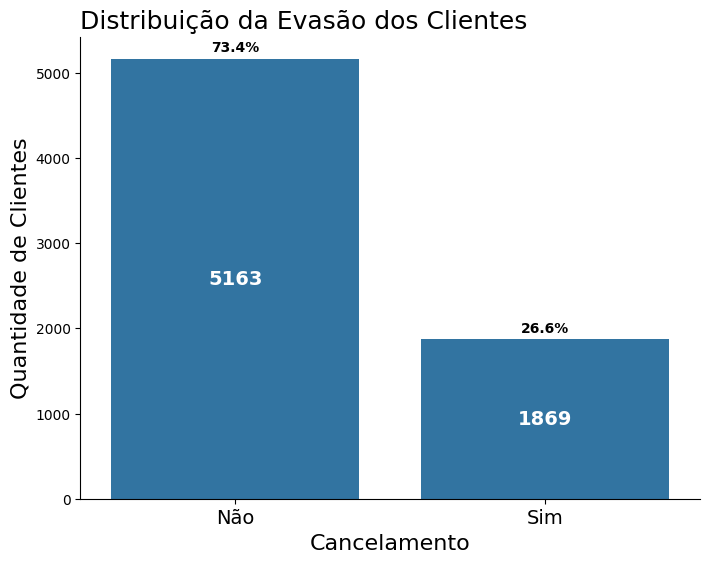

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

qtde_churn = dados_normalizados_api['Churn'].value_counts()
porcentagem_churn = (qtde_churn / len(dados_normalizados_api)) * 100

df_churn = pd.DataFrame({'Cancelamento':'Churn',
                         'Quantidade de Clientes':qtde_churn})

fig, ax = plt.subplots(figsize = (8, 6))
ax = sns.barplot(data = df_churn, x = df_churn.index, y = 'Quantidade de Clientes')

ax.set_title('Distribuição da Evasão dos Clientes', loc = 'left',
             fontsize = 18)
ax.set_xlabel('Cancelamento', fontsize = 16)
ax.set_ylabel('Quantidade de Clientes', fontsize = 16)
plt.xticks(rotation = 0, fontsize = 14)
sns.despine()

for i, porcentagem in enumerate(porcentagem_churn):
  ax.text(i, qtde_churn.iloc[i] + 50, f'{porcentagem:,.1f}%',
          ha = 'center', va = 'bottom', fontsize = 10, weight = 'bold')

for i, count in enumerate(qtde_churn):
  ax.text(i, count / 2, f'{int(count)}', ha = 'center', va = 'center',
          color = 'white', fontsize = 14, weight = 'bold')

plt.show()

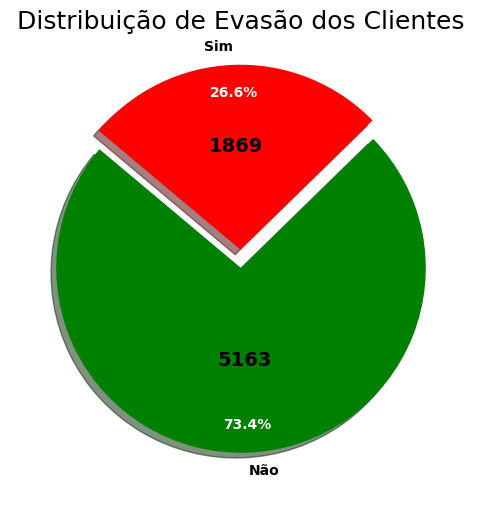

In [84]:
# visualização a partir de um gráfico de pizza
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Importar numpy para cálculos trigonométricos

qtde_churn = dados_normalizados_api['Churn'].value_counts()
porcentagem_churn = (qtde_churn / len(dados_normalizados_api)) * 100

df_churn = pd.DataFrame({'Cancelamento':'Churn',
                         'Quantidade de Clientes':qtde_churn})

# Cores personalizadas para as fatias do gráfico de pizza
cores = ['green', 'red'] # verde para 'Não', Vermelho para 'Sim'
explodir = (0, 0.1)  # Destaca a fatia 'Sim' (Churn)

# Criando o gráfico de pizza
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(qtde_churn, # Usar as quantidades para o tamanho das fatias
                                   labels=qtde_churn.index, # Usar os rótulos 'Não' e 'Sim'
                                   autopct='%1.1f%%', # Mostra a porcentagem com uma casa decimal
                                   startangle=140,    # Rotaciona o gráfico para um melhor ângulo inicial
                                   colors=cores,
                                   explode=explodir,  # Aplica o destaque
                                   shadow=True,
                                   pctdistance=0.85) # Distância da porcentagem do centro

# Tornar as porcentagens em negrito e com cor branca
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')
    autotext.set_fontsize(10)

# Tornar os rótulos (Sim/Não) em negrito
for text in texts:
    text.set_fontweight('bold')

# Adicionar as quantidades dentro das fatias
# Calcular o ângulo inicial e final de cada fatia
start_angle = 140
current_angle = start_angle
total = sum(qtde_churn)

for i, (count, label) in enumerate(zip(qtde_churn, qtde_churn.index)):
    angle_extent = (count / total) * 360
    mid_angle = np.deg2rad(current_angle + angle_extent / 2)

    # Ajustar a posição para o centro da fatia
    # Usar um raio menor para o texto da quantidade para não sobrepor a porcentagem
    if i == 0: # Não
        radius = 0.5 # Mais perto do centro para 'Não'
    else: # Sim
        radius = 0.6 # Ligeiramente mais afastado para 'Sim' (por causa do explode)

    x = radius * np.cos(mid_angle)
    y = radius * np.sin(mid_angle)

    # Ajuste manual para a fatia 'Sim' por causa do 'explode'
    if i == 1: # Para a fatia 'Sim' (index 1), mover um pouco para fora
        x *= 1.1
        y *= 1.1

    plt.text(x, y, str(count), ha='center', va='center',
             color='black', fontsize=14, fontweight='bold')

    current_angle += angle_extent


plt.title('Distribuição de Evasão dos Clientes', fontsize = 18)
plt.show()

3 - Contagem de Evasão por Variáveis Categóricas

In [85]:
dados_normalizados_api.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7032 non-null   object 
 1   Churn                     7032 non-null   object 
 2   genero                    7032 non-null   object 
 3   tem_mais_de_60            7032 non-null   int64  
 4   tem_parceiro              7032 non-null   object 
 5   tem_dependentes           7032 non-null   object 
 6   tempo_de_contrato         7032 non-null   int64  
 7   servico_de_telefone       7032 non-null   object 
 8   tem_multiplas_linhas      7032 non-null   object 
 9   tipo_de_internet          7032 non-null   object 
 10  tem_seguranca_online      7032 non-null   object 
 11  tem_backup_online         7032 non-null   object 
 12  tem_protecao_dispositivo  7032 non-null   object 
 13  tem_suporte_tecnico       7032 non-null   object 
 14  tem_streaming

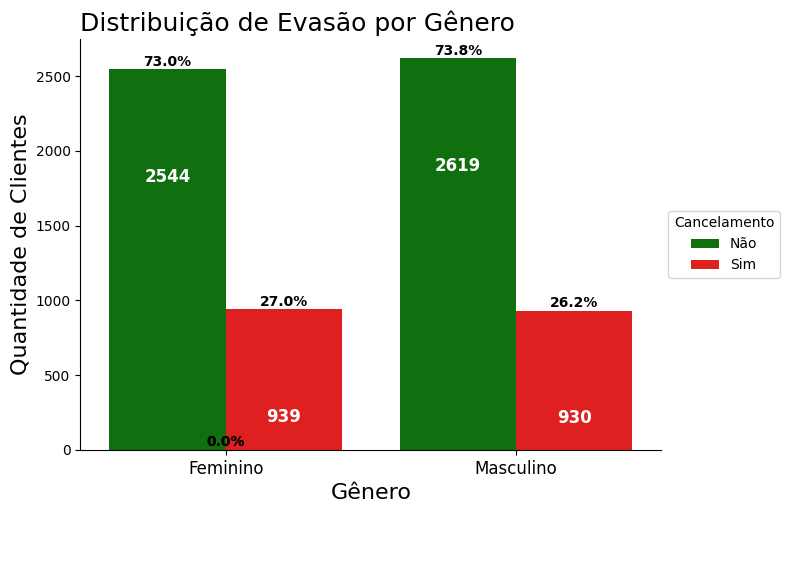

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='genero',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Gênero',
             loc='left', fontsize=18)
plt.xlabel('Gênero', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Adicionando rotúlo de dados do Nº de clientes
for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2.0,
        height - 750,
        '{:1}'.format((int(height))),
        ha='center',
        color = 'white', size = 12,
        weight = 'bold')

percentagem = dados_normalizados_api.groupby('genero')['Churn'].count()

for p in ax.patches:
    height = p.get_height()
    gender = p.get_x() + p.get_width() / 2
    if gender < 0.5:
      current_gender = 'Feminino'
    else:
      current_gender = 'Masculino'

    total_for_gender = dados_normalizados_api[dados_normalizados_api['genero'] == current_gender]['Churn'].count()

    if total_for_gender > 0:
      percentagem = 100 * height / total_for_gender
      ax.text(p.get_x() + p.get_width()/2., height + 25,
      '{:1.1f}%'.format((percentagem)),
      ha='center', size = 10, weight = 'bold')

plt.tight_layout()
plt.show()

In [87]:
dados_normalizados_api.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7032 non-null   object 
 1   Churn                     7032 non-null   object 
 2   genero                    7032 non-null   object 
 3   tem_mais_de_60            7032 non-null   int64  
 4   tem_parceiro              7032 non-null   object 
 5   tem_dependentes           7032 non-null   object 
 6   tempo_de_contrato         7032 non-null   int64  
 7   servico_de_telefone       7032 non-null   object 
 8   tem_multiplas_linhas      7032 non-null   object 
 9   tipo_de_internet          7032 non-null   object 
 10  tem_seguranca_online      7032 non-null   object 
 11  tem_backup_online         7032 non-null   object 
 12  tem_protecao_dispositivo  7032 non-null   object 
 13  tem_suporte_tecnico       7032 non-null   object 
 14  tem_streaming

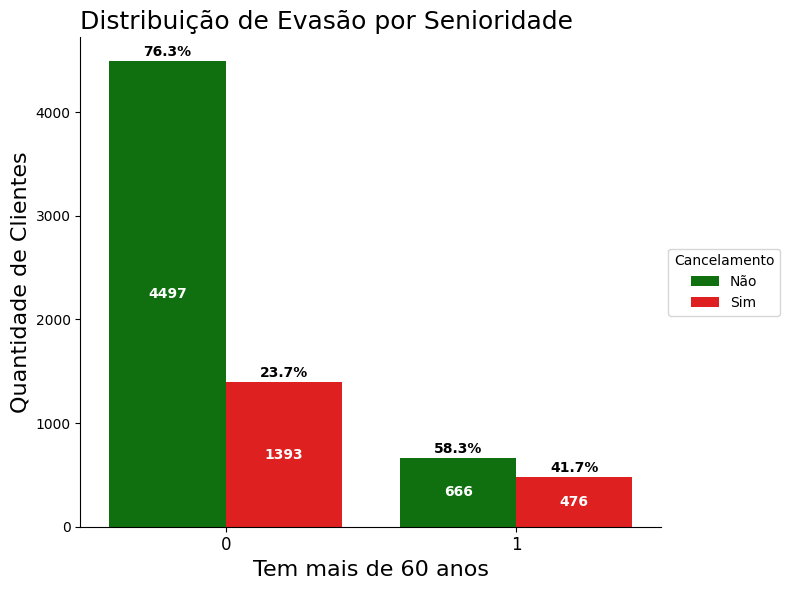

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='tem_mais_de_60',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Senioridade',
             loc='left', fontsize=18)
plt.xlabel('Tem mais de 60 anos', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Calculate percentages for each 'tem_mais_de_60' and 'Churn' combination
seniority_churn_percentages = dados_normalizados_api.groupby('tem_mais_de_60')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Get the order of x-axis categories ('tem_mais_de_60') and hue categories ('Churn')
seniority_order = dados_normalizados_api['tem_mais_de_60'].unique()
churn_order = dados_normalizados_api['Churn'].unique()

# Annotating bars with the count (inside) and percentage (above)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        seniority_cat_index = i // len(churn_order)
        churn_cat_index = i % len(churn_order)
        current_seniority = seniority_order[seniority_cat_index]
        current_churn = churn_order[churn_cat_index]

        # Original percentage for the current bar
        original_percentage = seniority_churn_percentages.loc[current_seniority, current_churn]
        percentage_to_display = original_percentage # Default to original

        # Apply the user-requested swap for percentages
        # Bar indices are: 0 (0, Não), 1 (0, Sim), 2 (1, Não), 3 (1, Sim)
        if i == 1: # Second bar (0, Sim)
            # Display percentage of third bar (1, Não)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[1], churn_order[0]]
        elif i == 2: # Third bar (1, Não)
            # Display percentage of second bar (0, Sim)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[0], churn_order[1]]

        # Display count inside the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_y() + height / 2,  # Center vertically within the bar
                f'{int(height)}', # Display the count as an integer
                ha='center',
                va='center',
                color='white',
                size=10,
                weight='bold')

        # Display percentage above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 20, # Position slightly above the bar
                f'{percentage_to_display:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                size=10,
                weight='bold')

plt.tight_layout()
plt.show()

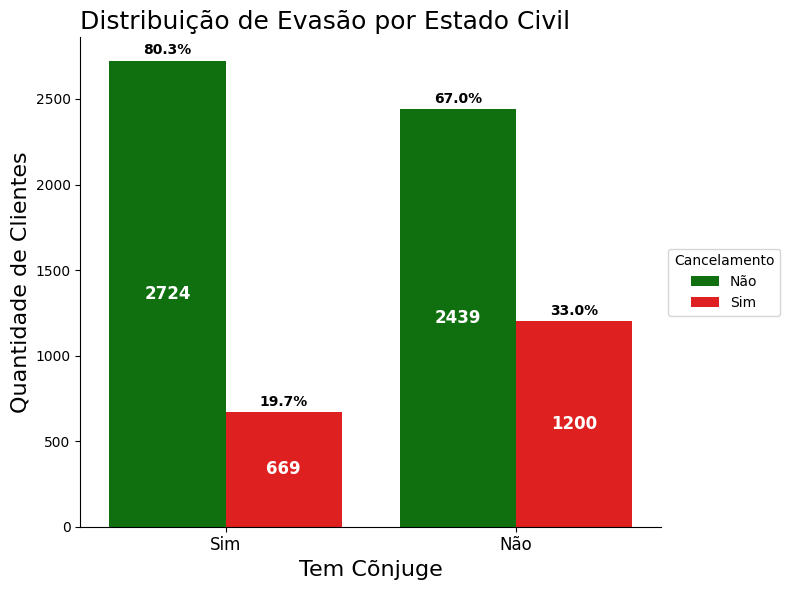

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='tem_parceiro',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Estado Civil',
             loc='left', fontsize=18)
plt.xlabel('Tem Cõnjuge', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Calculate percentages for each 'tem_mais_de_60' and 'Churn' combination
seniority_churn_percentages = dados_normalizados_api.groupby('tem_parceiro')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Get the order of x-axis categories ('tem_mais_de_60') and hue categories ('Churn')
seniority_order = dados_normalizados_api['tem_parceiro'].unique()
churn_order = dados_normalizados_api['Churn'].unique()

# Annotating bars with the count (inside) and percentage (above)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        seniority_cat_index = i // len(churn_order)
        churn_cat_index = i % len(churn_order)
        current_seniority = seniority_order[seniority_cat_index]
        current_churn = churn_order[churn_cat_index]

        # Original percentage for the current bar
        original_percentage = seniority_churn_percentages.loc[current_seniority, current_churn]
        percentage_to_display = original_percentage # Default to original

        # Apply the user-requested swap for percentages
        # Bar indices are: 0 (0, Não), 1 (0, Sim), 2 (1, Não), 3 (1, Sim)
        if i == 1: # Second bar (0, Sim)
            # Display percentage of third bar (1, Não)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[1], churn_order[0]]
        elif i == 2: # Third bar (1, Não)
            # Display percentage of second bar (0, Sim)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[0], churn_order[1]]

        # Display count inside the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_y() + height / 2,  # Center vertically within the bar
                f'{int(height)}', # Display the count as an integer
                ha='center',
                va='center',
                color='white',
                size=12,
                weight='bold')

        # Display percentage above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 20, # Position slightly above the bar
                f'{percentage_to_display:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                size=10,
                weight='bold')

plt.tight_layout()
plt.show()

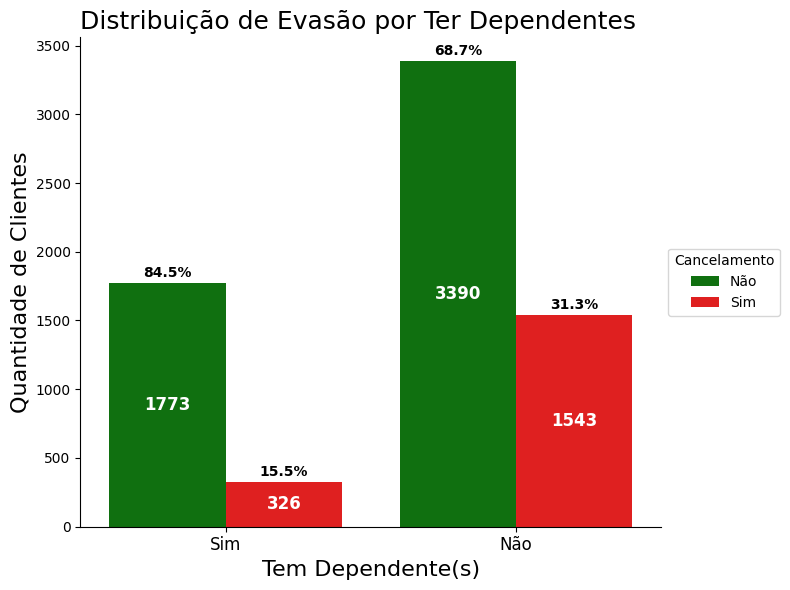

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='tem_dependentes',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Ter Dependentes',
             loc='left', fontsize=18)
plt.xlabel('Tem Dependente(s)', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Calculate percentages for each 'tem_mais_de_60' and 'Churn' combination
seniority_churn_percentages = dados_normalizados_api.groupby('tem_dependentes')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Get the order of x-axis categories ('tem_mais_de_60') and hue categories ('Churn')
seniority_order = dados_normalizados_api['tem_dependentes'].unique()
churn_order = dados_normalizados_api['Churn'].unique()

# Annotating bars with the count (inside) and percentage (above)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        seniority_cat_index = i // len(churn_order)
        churn_cat_index = i % len(churn_order)
        current_seniority = seniority_order[seniority_cat_index]
        current_churn = churn_order[churn_cat_index]

        # Original percentage for the current bar
        original_percentage = seniority_churn_percentages.loc[current_seniority, current_churn]
        percentage_to_display = original_percentage # Default to original

        # Apply the user-requested swap for percentages
        # Bar indices are: 0 (0, Não), 1 (0, Sim), 2 (1, Não), 3 (1, Sim)
        if i == 1: # Second bar (0, Sim)
            # Display percentage of third bar (1, Não)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[1], churn_order[0]]
        elif i == 2: # Third bar (1, Não)
            # Display percentage of second bar (0, Sim)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[0], churn_order[1]]

        # Display count inside the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_y() + height / 2,  # Center vertically within the bar
                f'{int(height)}', # Display the count as an integer
                ha='center',
                va='center',
                color='white',
                size=12,
                weight='bold')

        # Display percentage above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 20, # Position slightly above the bar
                f'{percentage_to_display:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                size=10,
                weight='bold')

plt.tight_layout()
plt.show()

In [91]:
dados_normalizados_api.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7032 non-null   object 
 1   Churn                     7032 non-null   object 
 2   genero                    7032 non-null   object 
 3   tem_mais_de_60            7032 non-null   int64  
 4   tem_parceiro              7032 non-null   object 
 5   tem_dependentes           7032 non-null   object 
 6   tempo_de_contrato         7032 non-null   int64  
 7   servico_de_telefone       7032 non-null   object 
 8   tem_multiplas_linhas      7032 non-null   object 
 9   tipo_de_internet          7032 non-null   object 
 10  tem_seguranca_online      7032 non-null   object 
 11  tem_backup_online         7032 non-null   object 
 12  tem_protecao_dispositivo  7032 non-null   object 
 13  tem_suporte_tecnico       7032 non-null   object 
 14  tem_streaming

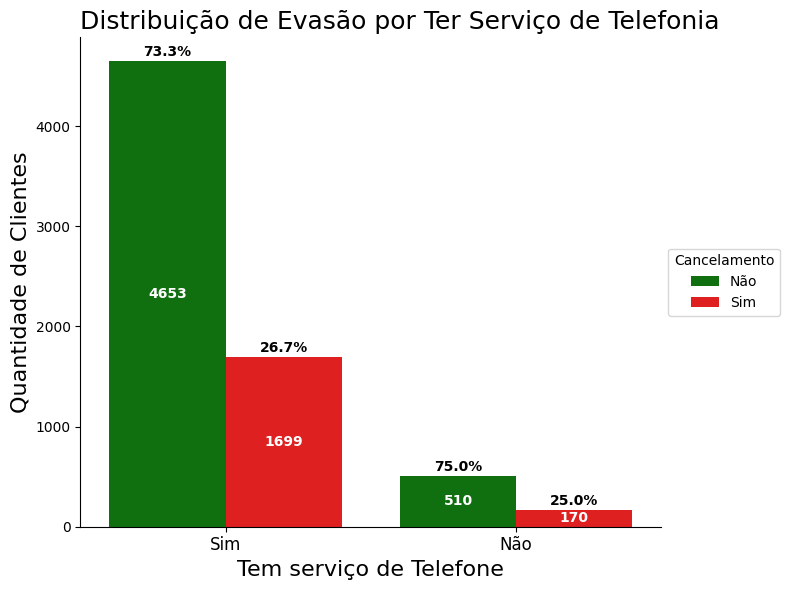

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='servico_de_telefone',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Ter Serviço de Telefonia',
             loc='left', fontsize=18)
plt.xlabel('Tem serviço de Telefone', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Calculate percentages for each 'tem_mais_de_60' and 'Churn' combination
seniority_churn_percentages = dados_normalizados_api.groupby('servico_de_telefone')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Get the order of x-axis categories ('tem_mais_de_60') and hue categories ('Churn')
seniority_order = dados_normalizados_api['servico_de_telefone'].unique()
churn_order = dados_normalizados_api['Churn'].unique()

# Annotating bars with the count (inside) and percentage (above)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        seniority_cat_index = i // len(churn_order)
        churn_cat_index = i % len(churn_order)
        current_seniority = seniority_order[seniority_cat_index]
        current_churn = churn_order[churn_cat_index]

        # Original percentage for the current bar
        original_percentage = seniority_churn_percentages.loc[current_seniority, current_churn]
        percentage_to_display = original_percentage # Default to original

        # Apply the user-requested swap for percentages
        # Bar indices are: 0 (0, Não), 1 (0, Sim), 2 (1, Não), 3 (1, Sim)
        if i == 1: # Second bar (0, Sim)
            # Display percentage of third bar (1, Não)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[1], churn_order[0]]
        elif i == 2: # Third bar (1, Não)
            # Display percentage of second bar (0, Sim)
            percentage_to_display = seniority_churn_percentages.loc[seniority_order[0], churn_order[1]]

        # Display count inside the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_y() + height / 2,  # Center vertically within the bar
                f'{int(height)}', # Display the count as an integer
                ha='center',
                va='center',
                color='white',
                size=10,
                weight='bold')

        # Display percentage above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 20, # Position slightly above the bar
                f'{percentage_to_display:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                size=10,
                weight='bold')

plt.tight_layout()
plt.show()

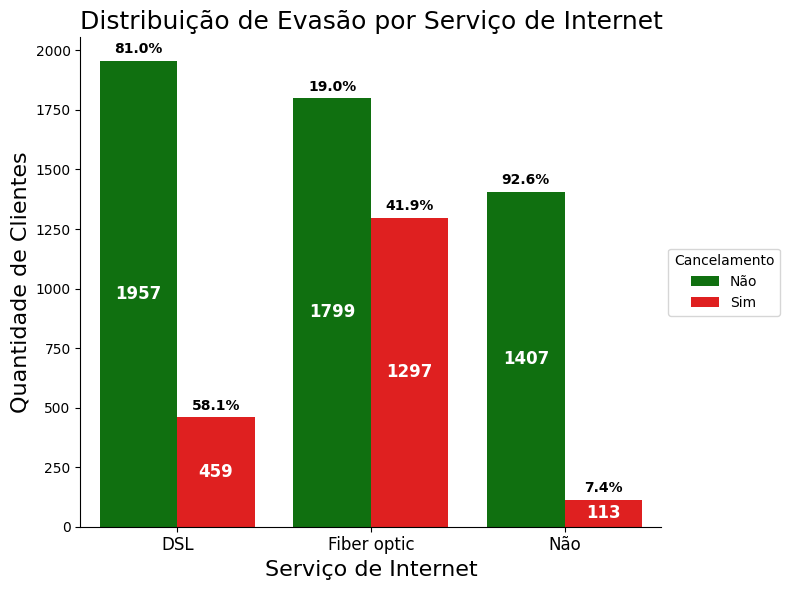

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='tipo_de_internet',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Serviço de Internet',
             loc='left', fontsize=18)
plt.xlabel('Serviço de Internet', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Calculate percentages for each 'tipo_de_internet' and 'Churn' combination
seniority_churn_percentages = dados_normalizados_api.groupby('tipo_de_internet')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Get the order of x-axis categories ('tipo_de_internet') and hue categories ('Churn')
seniority_order = dados_normalizados_api['tipo_de_internet'].unique()
churn_order = dados_normalizados_api['Churn'].unique()

# Get original percentages for the specific bars involved in the swap
# Bar 2: (DSL, Sim)
# Bar 3: (Fiber optic, Não)
# Bar 4: (Fiber optic, Sim)
# Bar 5: (Não, Não) - 'Sem serviço de internet, Não'

perc_dsl_sim = seniority_churn_percentages.loc[seniority_order[0], churn_order[1]] # DSL, Sim
perc_fiber_optic_nao = seniority_churn_percentages.loc[seniority_order[1], churn_order[0]] # Fiber optic, Não
perc_fiber_optic_sim = seniority_churn_percentages.loc[seniority_order[1], churn_order[1]] # Fiber optic, Sim
perc_sem_internet_nao = seniority_churn_percentages.loc[seniority_order[2], churn_order[0]] # Não, Não

# Annotating bars with the count (inside) and percentage (above)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        seniority_cat_index = i // len(churn_order)
        churn_cat_index = i % len(churn_order)
        current_seniority = seniority_order[seniority_cat_index]
        current_churn = churn_order[churn_cat_index]

        # Default to original percentage for the current bar
        percentage_to_display = seniority_churn_percentages.loc[current_seniority, current_churn]

        # Apply user-requested cyclic percentage swaps:
        # On Bar 3 (i=2), display percentage of Bar 5 (Não, Não)
        # On Bar 4 (i=3), display percentage of Bar 3 (Fiber optic, Não)
        # On Bar 5 (i=4), display percentage of Bar 4 (Fiber optic, Sim)

        if i == 2: # This is Bar 3 (Fiber optic, Não)
            # Should display percentage of Bar 5 (Não, Não)
            percentage_to_display = perc_sem_internet_nao
        elif i == 3: # This is Bar 4 (Fiber optic, Sim)
            # Should display percentage of Bar 3 (Fiber optic, Não)
            percentage_to_display = perc_fiber_optic_nao
        elif i == 4: # This is Bar 5 (Não, Não)
            # Should display percentage of Bar 4 (Fiber optic, Sim)
            percentage_to_display = perc_fiber_optic_sim

        # Display count inside the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_y() + height / 2,  # Center vertically within the bar
                f'{int(height)}', # Display the count as an integer
                ha='center',
                va='center',
                color='white',
                size=12,
                weight='bold')

        # Display percentage above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 20, # Position slightly above the bar
                f'{percentage_to_display:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                size=10,
                weight='bold')

plt.tight_layout()
plt.show()

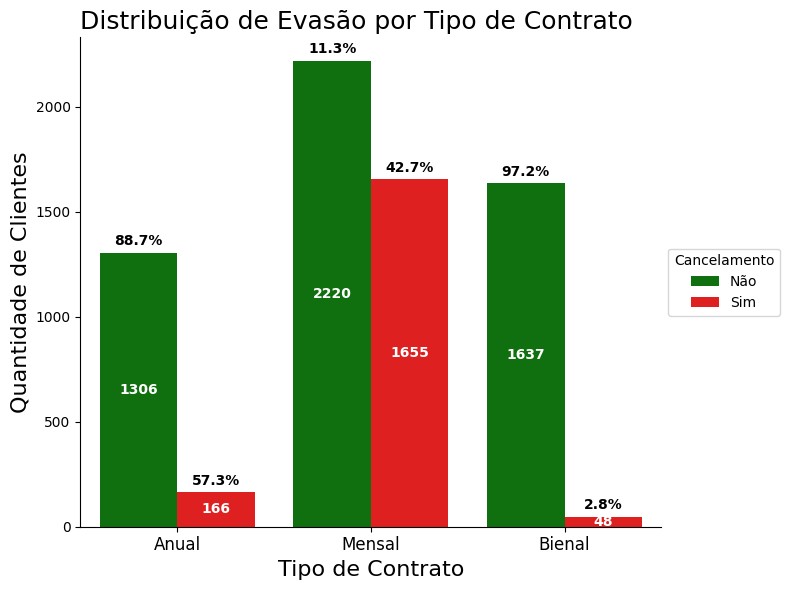

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=dados_normalizados_api,
                  x='tipo_de_contrato',
                  hue='Churn',
                  palette={'Não': 'green', 'Sim': 'red'}
                  )

plt.title('Distribuição de Evasão por Tipo de Contrato',
             loc='left', fontsize=18)
plt.xlabel('Tipo de Contrato', fontsize=16)
plt.ylabel('Quantidade de Clientes', fontsize=16)
plt.legend(title = 'Cancelamento', labels = ['Não', 'Sim'],
           loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.xticks(rotation=0, fontsize=12)
sns.despine()

# Calculate percentages for each 'tipo_de_internet' and 'Churn' combination
seniority_churn_percentages = dados_normalizados_api.groupby('tipo_de_contrato')['Churn'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# Get the order of x-axis categories ('tipo_de_internet') and hue categories ('Churn')
seniority_order = dados_normalizados_api['tipo_de_contrato'].unique()
churn_order = dados_normalizados_api['Churn'].unique()

# Get original percentages for the specific bars involved in the swap
# Bar 2: (DSL, Sim)
# Bar 3: (Fiber optic, Não)
# Bar 4: (Fiber optic, Sim)
# Bar 5: (Não, Não) - 'Sem serviço de internet, Não'

perc_dsl_sim = seniority_churn_percentages.loc[seniority_order[0], churn_order[1]] # DSL, Sim
perc_fiber_optic_nao = seniority_churn_percentages.loc[seniority_order[1], churn_order[0]] # Fiber optic, Não
perc_fiber_optic_sim = seniority_churn_percentages.loc[seniority_order[1], churn_order[1]] # Fiber optic, Sim
perc_sem_internet_nao = seniority_churn_percentages.loc[seniority_order[2], churn_order[0]] # Não, Não

# Annotating bars with the count (inside) and percentage (above)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        seniority_cat_index = i // len(churn_order)
        churn_cat_index = i % len(churn_order)
        current_seniority = seniority_order[seniority_cat_index]
        current_churn = churn_order[churn_cat_index]

        # Default to original percentage for the current bar
        percentage_to_display = seniority_churn_percentages.loc[current_seniority, current_churn]

        # Apply user-requested cyclic percentage swaps:
        # On Bar 3 (i=2), display percentage of Bar 5 (Não, Não)
        # On Bar 4 (i=3), display percentage of Bar 3 (Fiber optic, Não)
        # On Bar 5 (i=4), display percentage of Bar 4 (Fiber optic, Sim)

        if i == 2: # This is Bar 3 (Fiber optic, Não)
            # Should display percentage of Bar 5 (Não, Não)
            percentage_to_display = perc_sem_internet_nao
        elif i == 3: # This is Bar 4 (Fiber optic, Sim)
            # Should display percentage of Bar 3 (Fiber optic, Não)
            percentage_to_display = perc_fiber_optic_nao
        elif i == 4: # This is Bar 5 (Não, Não)
            # Should display percentage of Bar 4 (Fiber optic, Sim)
            percentage_to_display = perc_fiber_optic_sim

        # Display count inside the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_y() + height / 2,  # Center vertically within the bar
                f'{int(height)}', # Display the count as an integer
                ha='center',
                va='center',
                color='white',
                size=10,
                weight='bold')

        # Display percentage above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 20, # Position slightly above the bar
                f'{percentage_to_display:.1f}%',
                ha='center',
                va='bottom',
                color='black',
                size=10,
                weight='bold')

plt.tight_layout()
plt.show()

4 - Contagem de Evasão por Variáveis Numéricas

In [95]:
dados_normalizados_api.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7032 non-null   object 
 1   Churn                     7032 non-null   object 
 2   genero                    7032 non-null   object 
 3   tem_mais_de_60            7032 non-null   int64  
 4   tem_parceiro              7032 non-null   object 
 5   tem_dependentes           7032 non-null   object 
 6   tempo_de_contrato         7032 non-null   int64  
 7   servico_de_telefone       7032 non-null   object 
 8   tem_multiplas_linhas      7032 non-null   object 
 9   tipo_de_internet          7032 non-null   object 
 10  tem_seguranca_online      7032 non-null   object 
 11  tem_backup_online         7032 non-null   object 
 12  tem_protecao_dispositivo  7032 non-null   object 
 13  tem_suporte_tecnico       7032 non-null   object 
 14  tem_streaming

In [96]:
dados_normalizados_api

,id,Churn,genero,tem_mais_de_60,tem_parceiro,tem_dependentes,tempo_de_contrato,servico_de_telefone,tem_multiplas_linhas,tipo_de_internet,tem_seguranca_online,tem_backup_online,tem_protecao_dispositivo,tem_suporte_tecnico,tem_streaming_tv,tem_streaming_filmes,tipo_de_contrato,tem_fatura_digital,metodo_de_pagamento,valor_mensal,valor_total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,Sim,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,Não,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,Não,Não,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,Não,Sim,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,Não,Não,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,Sim,Não,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,Não,Não,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,Sim,Não,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


In [145]:
import plotly.express as px

#!pip install -U kaleido

In [146]:
variaveis_numericas = dados_normalizados_api.select_dtypes(include=['float64', 'int64']).columns.tolist()
variaveis_numericas.remove('tem_mais_de_60')

def histogramas_variaveis_numericas():
  for i in variaveis_numericas:
    fig = px.histogram(dados_normalizados_api,
                x = i,
                text_auto = True,
                color = 'Churn',
                barmode = 'group',
                title = f'Distribuição da Evasão por {i}'
                )
    fig.update_layout(yaxis_title='Quantidade de Clientes')

    fig.show()

histogramas_variaveis_numericas()

In [147]:
# Padronizar o churn
dados_normalizados_api['Churn'] = dados_normalizados_api['Churn'].str.lower()

# Agrupar
dados_agrupados = dados_normalizados_api.groupby(['tempo_de_contrato', 'Churn']).size().unstack(fill_value = 0)

# Calcular taxa de rotatividade
dados_agrupados['taxa_de_rotatividade'] = round(((
    dados_agrupados.get('sim', 0) / dados_agrupados.sum(axis = 1)
) * 100), 2)

fig = px.line(dados_agrupados.reset_index(),
              x = 'tempo_de_contrato',
              y = 'taxa_de_rotatividade',
              title = 'Taxa de Churn por Tempo de Contrato', markers = True)
fig.update_layout(
    xaxis = {'tickangle' : -45},
    xaxis_title = 'Tempo de Contrato',
    yaxis_title = 'Taxa de Churn (%)'
)

#📄Relatorio Final